In [16]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering#means bottom up

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram,linkage


In [3]:
data = pd.read_csv(r"c:\Users\v_bha\Downloads\Wholesale_Data_with_Missing_Values (2).csv")

print(data)

     Channel  Region    Fresh     Milk  Grocery   Frozen  Detergents_Paper  \
0        2.0     3.0  12669.0   9656.0   7561.0    214.0            2674.0   
1        2.0     3.0   7057.0   9810.0   9568.0   1762.0            3293.0   
2        2.0     3.0   6353.0   8808.0   7684.0   2405.0            3516.0   
3        1.0     3.0  13265.0   1196.0   4221.0   6404.0             507.0   
4        2.0     3.0  22615.0   5410.0   7198.0   3915.0            1777.0   
..       ...     ...      ...      ...      ...      ...               ...   
435      1.0     3.0  29703.0  12051.0      NaN  13135.0             182.0   
436      1.0     3.0  39228.0   1431.0    764.0   4510.0               NaN   
437      2.0     3.0  14531.0  15488.0  30243.0    437.0           14841.0   
438      1.0     3.0  10290.0   1981.0   2232.0      NaN             168.0   
439      1.0     3.0   2787.0   1698.0   2510.0     65.0             477.0   

     Delicassen  
0        1338.0  
1        1776.0  
2        

In [4]:
print(data.isnull().sum())

Channel             22
Region              21
Fresh               22
Milk                25
Grocery             17
Frozen              24
Detergents_Paper    25
Delicassen          14
dtype: int64


In [5]:
#hndling missing values

fill_missing_values = SimpleImputer(strategy = "mean")

data = fill_missing_values.fit_transform(data)

In [6]:
#now scaling for the columns

scaling = StandardScaler()

data = scaling.fit_transform(data)

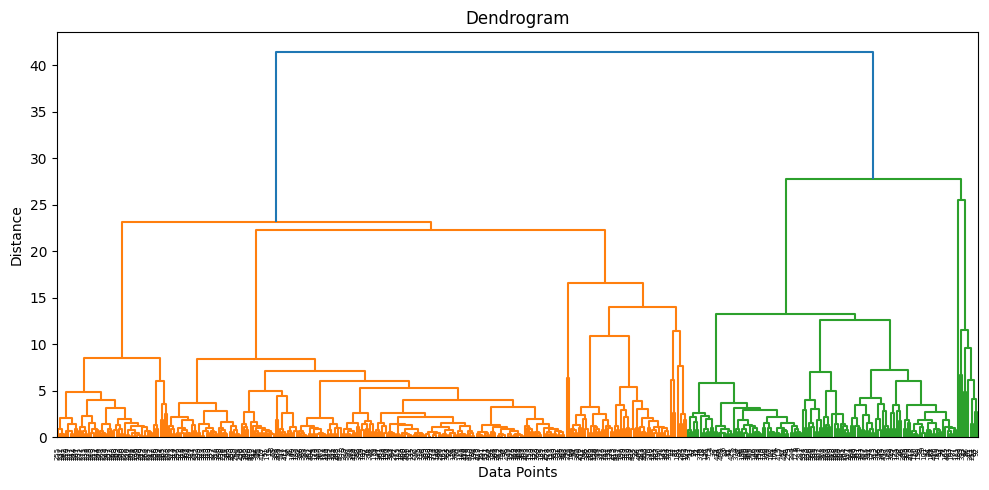

In [ ]:
#dendrogram shows the  digarma to get the idea what is the best values of k

#this dendrogram helps uss to see the weight of the split we should manully split it 

z = linkage(data,method = "ward")#this method is(one of the linkage) this linkage is used to check how far the clusters are


plt.figure(figsize=(10,5))
dendrogram(z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [ ]:
#we can see in the above dendrogram the final merge (weight is 41) and second merge is at 28 

#we chosse 2 because to merge this 28 and 41 there is big gap so we go with 2

In [18]:
data = pd.DataFrame(data)



In [19]:
model = AgglomerativeClustering(n_clusters = 2,metric = "euclidean",linkage = "ward")

output = model.fit_predict(data)

data["Cluster"] = output




In [20]:
silhouette  = silhouette_score(data,output)

print(silhouette )

0.3815063039935923
